# 4 &middot; Elastostatics as a Minimization Problem

Posing an elastic object is an **optimization**: pin part of the shape, drag a **handle**, and let
everything else settle at the vertex positions $x$ that minimize the energy below. The pin and handle
terms are quadratic *spring* penalties of stiffness $K$. We minimize with Newton (how that solve works is
tutorial 5's job) and focus on how **different energies pose differently**.

$$
E(x) = \underbrace{E_{\text{elastic}}(x)}_{\text{wants rest shape}}
     + \underbrace{\tfrac{K}{2}\lVert x_{\text{pin}} - p\rVert^2}_{\text{hold pins}}
     + \underbrace{\tfrac{K}{2}\lVert x_{\text{handle}} - h\rVert^2}_{\text{drag handle}}.
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import igl
import simkit
import utils

NOTEBOOK = "004_elastostatics_minimization"                        # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)               # results/004_elastostatics_minimization/
MEDIA_DIR = "media"                                                # tracked copies for the website
# material and springs
MU, LAM = 1.0, 1.0                              # Lame parameters, the same on every element
K_PIN = 1e5                                     # stiffness of the pin and handle springs
POSE_MATERIAL = "macklin-mueller-neo-hookean"   # simkit material of both animations
MATERIALS = {"Linear": "linear-elasticity",     # plot label -> simkit material, for the comparison
             "ARAP": "arap",
             "Neo-Hookean": "macklin-mueller-neo-hookean"}
# solver and checks
NEWTON_ITERS = 100                              # max Newton iterations per pose
NEWTON_TOL = 1e-6                               # stop when the Newton step is shorter than this
FD_STEP = 1e-6                                  # central-difference step of the gradient check
FD_NOISE = 0.1                                  # size of the random deformation the check runs at
SEED = 0                                        # seed of that random deformation
# triangle experiments
N_FRAMES = 48                                   # handle positions per animation
FIG8_AMP = (0.45, 0.6)                          # figure-8 half-width (x) and half-height (y)
FAR_TARGET = np.array([1.5, 1.1])               # handle target of the material comparison
# beam experiment
NX, NY = 16, 5                                  # grid resolution (vertices)
WIDTH, HEIGHT = 2.0, 0.4                        # beam size
SWING_DEG = 120                                 # largest swing angle of the right edge
FPS = 20                                        # video frame rate

## The posing system

`elastic_pose_system` builds the three terms of $E(x)$ from simkit: the elastic material (evaluated on
$F = Jx$ with the deformation Jacobian $J$ and weighted by element area), and two `simkit.dirichlet_penalty`
quadratics for the fixed pin and the movable handle. It returns the energy, gradient and Hessian closures
Newton needs, each summing its terms one per line (the Hessian is PSD-projected so Newton always goes
downhill). Re-aiming the handle just means building the system again; every later tutorial builds its
simulator this way.

In [2]:
def elastic_pose_system(X, T, material, pin_idx, pin_targets, handle_idx, handle_targets):
    """Elastic energy + a soft pin + a soft handle, in stacked vertex positions x."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    mu = np.full((len(T), 1), MU)
    lam = np.full((len(T), 1), LAM)
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, pin_targets, n, K_PIN)
    Q_handle, b_handle = simkit.dirichlet_penalty(handle_idx, handle_targets, n, K_PIN)

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, material)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_handle = simkit.energies.quadratic_energy(x, Q_handle, b_handle)
        E_total = E_elastic + E_pin + E_handle
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, material)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_handle = simkit.energies.quadratic_gradient(x, Q_handle, b_handle)
        g_total = g_elastic + g_pin + g_handle
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, material, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_handle = simkit.energies.quadratic_hessian(Q_handle)
        H_total = H_elastic + H_pin + H_handle
        return H_total

    return energy_func, gradient_func, hessian_func

## Two meshes

A single equilateral triangle (pin vertex 0, handle vertex 1) and a 16 &times; 5 cantilever beam from
`igl.triangulated_grid`, centered and scaled (pin the whole left edge, the whole right edge is the handle).
Blue squares mark pinned vertices, orange dots mark handles.

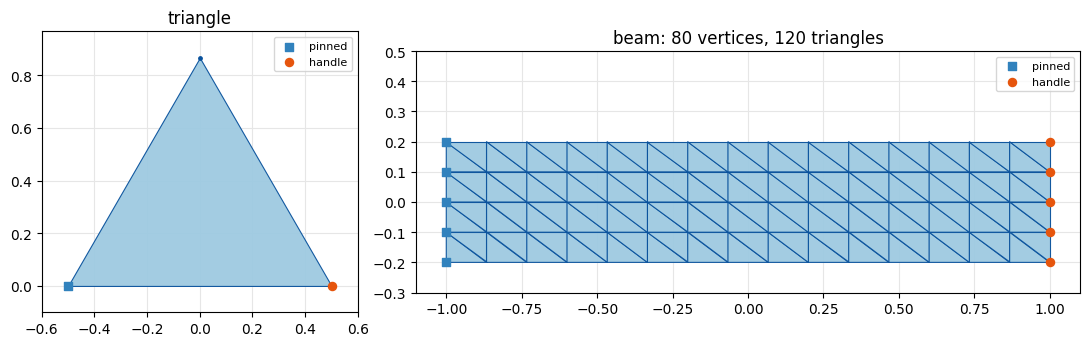

In [3]:
X_tri = np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])
T_tri = np.array([[0, 1, 2]])
tri_pin, tri_handle = np.array([0]), np.array([1])

V, T_beam = igl.triangulated_grid(NX, NY)                      # unit square, NX x NY vertices
X_beam = (V - 0.5) * np.array([WIDTH, HEIGHT])                 # centered WIDTH x HEIGHT rectangle
beam_pin = np.where(X_beam[:, 0] <= X_beam[:, 0].min() + 1e-6)[0]
beam_handle = np.where(X_beam[:, 0] >= X_beam[:, 0].max() - 1e-6)[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 2.1]})
utils.plot_mesh(axes[0], X_tri, T_tri, pins=tri_pin, handles=tri_handle, title="triangle", show_vertices=True)
utils.plot_mesh(axes[1], X_beam, T_beam, pins=beam_pin, handles=beam_handle, lims=((-1.1, 1.1), (-0.3, 0.5)),
                title=f"beam: {len(X_beam)} vertices, {len(T_beam)} triangles")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "004_meshes.png"))
plt.show()

## Check the gradient

Before posing anything, compare `gradient_func` with central finite differences (`simkit.gradient_cfd`)
of `energy_func` at a random deformation of the triangle, for each material, with the pin and handle
aimed at their rest positions so all three terms are active. Relative errors around $10^{-10}$ mean the
energy and gradient are consistent, which Newton and its line search rely on.

In [4]:
rng = np.random.default_rng(SEED)
x_test = (X_tri + FD_NOISE * rng.standard_normal(X_tri.shape)).reshape(-1, 1)
for label, material in MATERIALS.items():
    energy_func, gradient_func, hessian_func = elastic_pose_system(
        X_tri, T_tri, material, tri_pin, X_tri[tri_pin], tri_handle, X_tri[tri_handle])
    g = gradient_func(x_test)
    g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
    rel_err = np.linalg.norm(g_fd.reshape(-1, 1) - g) / np.linalg.norm(g)
    print(f"{label:12s} |g_fd - g| / |g| = {rel_err:.1e}")

Linear       |g_fd - g| / |g| = 2.6e-10
ARAP         |g_fd - g| / |g| = 4.0e-10
Neo-Hookean  |g_fd - g| / |g| = 4.4e-10


## A triangle: pin the left vertex, swing the right one in a figure-8

The handle traces a **figure-8** (a lemniscate), so the free apex both stretches and compresses. At each
handle position we build the system with the new target and re-solve, starting from the previous
equilibrium. The &times; is the handle's target, the orange dot where the handle vertex actually settles.

In [5]:
t = np.linspace(0, 2 * np.pi, N_FRAMES)
handle_path = X_tri[tri_handle] + np.stack([FIG8_AMP[0] * np.sin(t), FIG8_AMP[1] * np.sin(2 * t)], axis=1)

tri_states = []
U = X_tri.copy()
for h in handle_path:
    energy_func, gradient_func, hessian_func = elastic_pose_system(
        X_tri, T_tri, POSE_MATERIAL, tri_pin, X_tri[tri_pin], tri_handle, h[None])
    x = simkit.solvers.newton_solver(U.reshape(-1, 1), energy_func, gradient_func, hessian_func,
                                     tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS, do_line_search=True)
    U = x.reshape(-1, 2)
    tri_states.append(U)

fig, anim = utils.animate_mesh(tri_states, T_tri, lims=((-1.2, 1.6), (-1.2, 1.2)),
    title="Neo-Hookean triangle: handle traces a figure-8",
    pin_pts=X_tri[tri_pin], handle_traj=[s[tri_handle] for s in tri_states],
    target_pts=list(handle_path), fps=FPS, figsize=(6, 5))
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "triangle.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "004_triangle.mp4"))
plt.close(fig)
utils.embed_video(video)

Per frame: the elastic energy of each equilibrium (left), highest on the stretching right lobe of the
figure-8 (frames 1-23) and lower on the compressing left lobe (frames 24-46), and how far the pin and
handle vertices sit from their targets (right). Soft springs never hold exactly; they stretch by about
$\lVert\nabla E_{\text{elastic}}\rVert / K$, a few $10^{-6}$ here (zero at rest). The two curves coincide
because the elastic forces on a triangle sum to zero, so both springs pull equally hard.

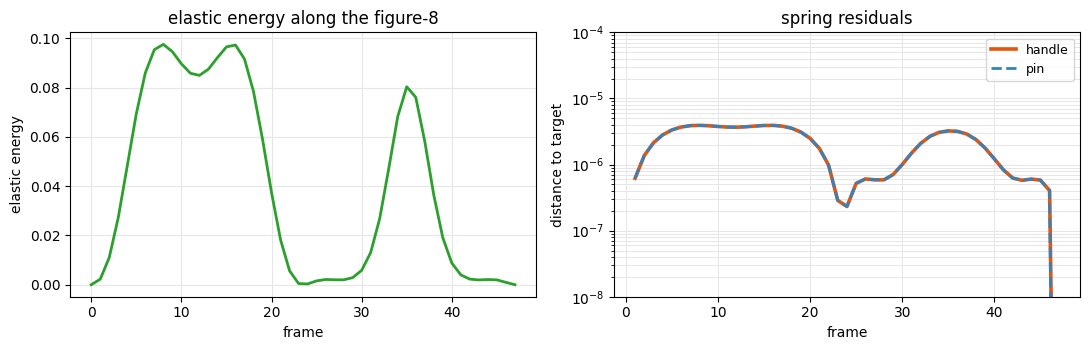

In [6]:
mu_tri = np.full((len(T_tri), 1), MU)
lam_tri = np.full((len(T_tri), 1), LAM)
tri_elastic = [simkit.energies.elastic_energy(X_tri, T_tri, mu_tri, lam_tri, POSE_MATERIAL, U) for U in tri_states]
tri_residuals = {
    "handle": [np.linalg.norm(U[tri_handle] - h[None], axis=1).max() for U, h in zip(tri_states, handle_path)],
    "pin": [np.linalg.norm(U[tri_pin] - X_tri[tri_pin], axis=1).max() for U in tri_states],
}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
frames = np.arange(N_FRAMES)
utils.line_plot(frames, {"Neo-Hookean": tri_elastic}, xlabel="frame", ylabel="elastic energy", ax=axes[0],
                title="elastic energy along the figure-8")
utils.residual_plot(tri_residuals, frames, ax=axes[1], colors={"handle": utils.HANDLE_C, "pin": utils.PIN_C},
                    xlabel="frame", ylabel="distance to target", title="spring residuals", ylim=(1e-8, 1e-4))
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "triangle_energy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "004_triangle_energy.png"))
plt.show()

## Same handle, three energies, very different poses

Pull the handle far up and to the right, and compare where the free apex lands under each model (dashed:
rest shape, &times;: handle target). We solve once per material from the rest shape, keeping each solve's
per-iteration gradients (`return_info=True`) for the convergence plot below.

Linear       free apex at (-0.45, +1.13), 2 Newton iterations
ARAP         free apex at (+0.08, +1.31), 5 Newton iterations
Neo-Hookean  free apex at (+0.19, +1.11), 4 Newton iterations


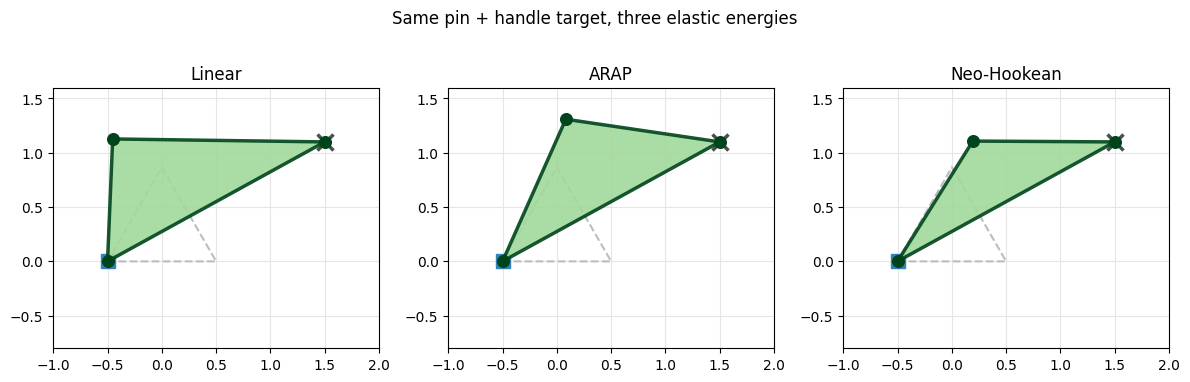

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
newton_grad_norms = {}
for ax, (label, material) in zip(axes, MATERIALS.items()):
    energy_func, gradient_func, hessian_func = elastic_pose_system(
        X_tri, T_tri, material, tri_pin, X_tri[tri_pin], tri_handle, FAR_TARGET[None])
    x, info = simkit.solvers.newton_solver(X_tri.reshape(-1, 1), energy_func, gradient_func, hessian_func,
                                           tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS, do_line_search=True,
                                           return_info=True)
    newton_grad_norms[label] = [np.linalg.norm(g) for g in info["g"]] + [np.linalg.norm(gradient_func(x))]
    U = x.reshape(-1, 2)
    utils.setup_axes(ax, (-1.0, 2.0), (-0.8, 1.6), title=label)
    utils.TriangleArtist(ax, U, rest=X_tri)
    ax.plot(*X_tri[tri_pin[0]], "s", color=utils.PIN_C, ms=10)
    ax.plot(*FAR_TARGET, "x", color="0.3", ms=12, mew=2.5)
    print(f"{label:12s} free apex at ({U[2, 0]:+.2f}, {U[2, 1]:+.2f}), {len(info['g'])} Newton iterations")
fig.suptitle("Same pin + handle target, three elastic energies")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "materials.png"),
                              copy_to=os.path.join(MEDIA_DIR, "004_materials.png"))
plt.show()

Linear elasticity is not rotation-invariant: it counts the large rotation this pose needs as strain, so
it poses a lopsided triangle, unlike the two rotation-invariant models ARAP and Neo-Hookean.

Gradient norm $\lVert\nabla E\rVert$ per Newton iteration for those three solves. It starts at
$K \lVert h - x_{\text{handle}}\rVert \approx 1.5 \times 10^5$ (the handle spring's pull) and falls by
about 16 orders of magnitude in 2 to 5 iterations. Linear elasticity is quadratic, so its first step already
lands on the minimum up to roundoff; the others end with Newton's fast local convergence (tutorial 5).

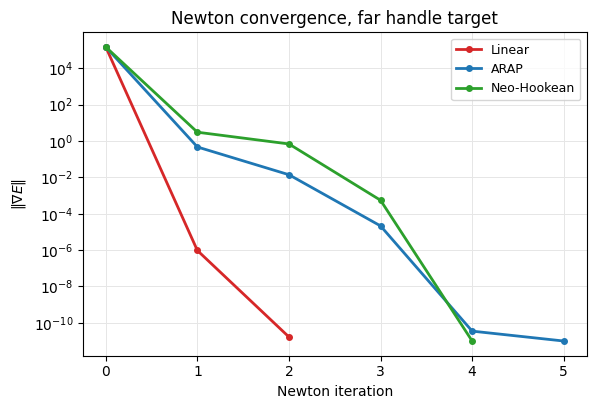

In [8]:
fig, ax = utils.residual_plot(newton_grad_norms, colors=utils.MAT_COLORS, markers=True, stagger=False,
                              xlabel="Newton iteration", ylabel=r"$\|\nabla E\|$",
                              title="Newton convergence, far handle target")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "newton_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "004_newton_convergence.png"))
plt.show()

## A cantilever beam: pin the left edge, swing the whole right edge

The handle is now **every vertex on the right edge**. We **rotate those target points about the origin**,
so the orange handles swing up and down in a wide arc: starting from rest, the angle sweeps to about
$\pm 120^\circ$ and back, whipping the beam through large bends. Targets are marked with &times;. Near the
deepest folds Newton needs up to 40 iterations, so we count them per pose; the printed line confirms that
none of the 48 solves stopped at the `NEWTON_ITERS` cap before its step fell below `NEWTON_TOL`.

In [9]:
angles = np.deg2rad(SWING_DEG) * np.sin(np.linspace(0, 2 * np.pi, N_FRAMES))

beam_states, beam_targets, beam_iters = [], [], []
n_capped = 0
U = X_beam.copy()
for th in angles:
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    targets = X_beam[beam_handle] @ R.T                         # right edge rotated by th about the origin
    energy_func, gradient_func, hessian_func = elastic_pose_system(
        X_beam, T_beam, POSE_MATERIAL, beam_pin, X_beam[beam_pin], beam_handle, targets)
    x, info = simkit.solvers.newton_solver(U.reshape(-1, 1), energy_func, gradient_func, hessian_func,
                                           tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS, do_line_search=True,
                                           return_info=True)
    last_step = np.linalg.norm(info["alphas"][-1] * info["dx"][-1])
    n_capped += int(last_step >= NEWTON_TOL)                    # stopped by the cap, not the tolerance
    beam_iters.append(info["iters"] + 1)
    U = x.reshape(-1, 2)
    beam_states.append(U)
    beam_targets.append(targets)
print(f"Newton iterations per pose: {min(beam_iters)} to {max(beam_iters)} (cap {NEWTON_ITERS}); "
      f"{n_capped} of {N_FRAMES} poses stopped at the cap")

fig, anim = utils.animate_mesh(beam_states, T_beam, lims=((-1.8, 1.8), (-1.8, 1.8)),
    title="Cantilever: right edge swung in an arc about the origin",
    pin_pts=X_beam[beam_pin], handle_traj=[s[beam_handle] for s in beam_states],
    target_pts=beam_targets, fps=FPS, figsize=(6, 6))
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "beam.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "004_beam.mp4"))
plt.close(fig)
utils.embed_video(video)

Newton iterations per pose: 1 to 40 (cap 100); 0 of 48 poses stopped at the cap


The beam's elastic energy against the swing angle (left): zero at rest, nearly symmetric in $\pm\theta$, and
the same on the way out and back, so each pose is a well-defined minimum rather than a record of the path.
Right: the worst pin and handle residuals per frame, below $10^{-6}$ and nearly equal (they vanish at the
rest frames, hence the drops at both ends), since the total forces of the two spring sets again balance.

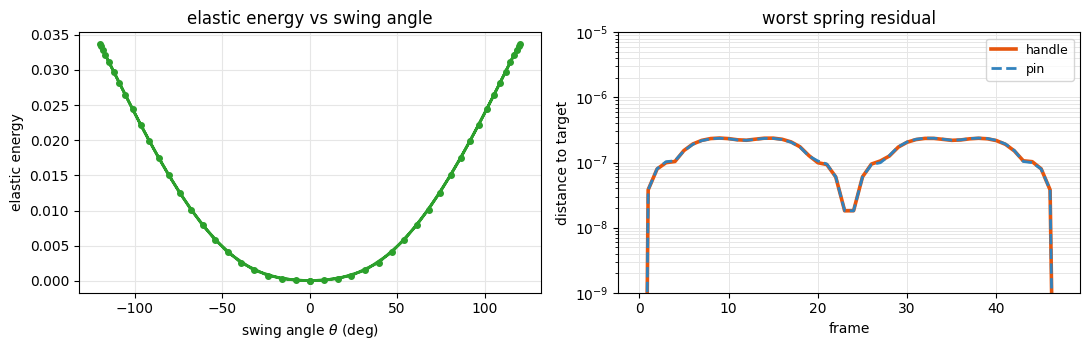

In [10]:
mu_beam = np.full((len(T_beam), 1), MU)
lam_beam = np.full((len(T_beam), 1), LAM)
beam_elastic = [simkit.energies.elastic_energy(X_beam, T_beam, mu_beam, lam_beam, POSE_MATERIAL, U) for U in beam_states]
beam_residuals = {
    "handle": [np.linalg.norm(U[beam_handle] - tg, axis=1).max() for U, tg in zip(beam_states, beam_targets)],
    "pin": [np.linalg.norm(U[beam_pin] - X_beam[beam_pin], axis=1).max() for U in beam_states],
}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
utils.line_plot(np.rad2deg(angles), {"Neo-Hookean": beam_elastic}, xlabel=r"swing angle $\theta$ (deg)",
                ylabel="elastic energy", markers=True, ax=axes[0], title="elastic energy vs swing angle")
utils.residual_plot(beam_residuals, frames, ax=axes[1], colors={"handle": utils.HANDLE_C, "pin": utils.PIN_C},
                    xlabel="frame", ylabel="distance to target", title="worst spring residual", ylim=(1e-9, 1e-5))
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "beam_energy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "004_beam_energy.png"))
plt.show()

The two per-element fields behind the beam's elastic energy $\sum_e \text{vol}_e\,\psi(F_e)$: the element
areas `vol` (uniform on this grid), and the energy density $\psi(F)$ at the largest bend, drawn on the
deformed beam. The energy concentrates at the inner corner of the fold, where the elements are crushed.

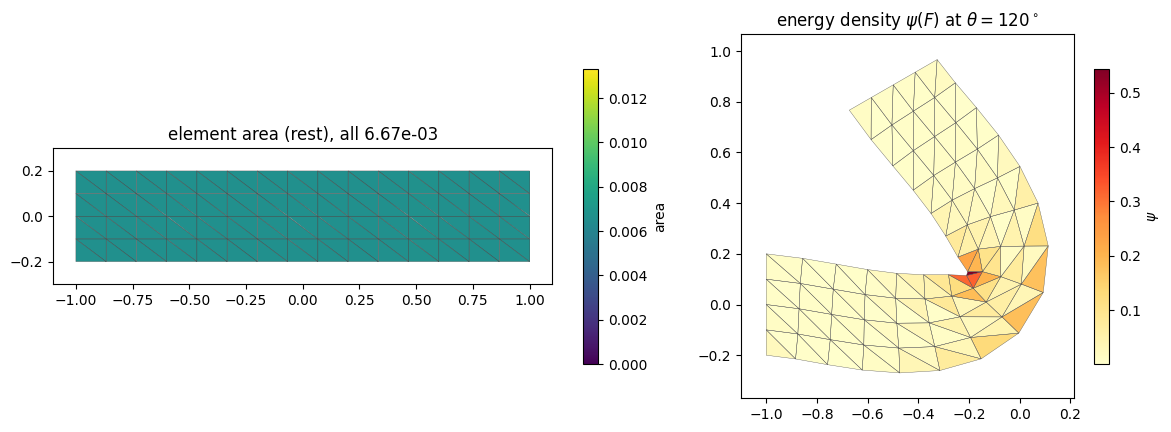

In [11]:
k = int(np.argmax(angles))
vol_beam = simkit.volume(X_beam, T_beam)
F = simkit.deformation_gradient(X_beam, T_beam, beam_states[k])
psi = simkit.energies.elastic_energy_element_F(F, mu_beam, lam_beam, POSE_MATERIAL)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
utils.plot_scalar_field(axes[0], X_beam, T_beam, vol_beam, vmin=0.0, vmax=2 * vol_beam.max(),
                        title=f"element area (rest), all {vol_beam.mean():.2e}", label="area")
utils.plot_scalar_field(axes[1], beam_states[k], T_beam, psi, cmap="YlOrRd",
                        title=rf"energy density $\psi(F)$ at $\theta = {np.rad2deg(angles[k]):.0f}^\circ$",
                        label=r"$\psi$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "beam_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "004_beam_fields.png"))
plt.show()

### Takeaways
* Posing = **minimizing** elastic energy + soft pin/handle springs, packaged as an `XXX_system`.
* The *same* setup with a *different* energy gives a *different* equilibrium.
* Soft springs leave small residuals of order $\lVert\nabla E_{\text{elastic}}\rVert/K$.
* We solved it with Newton without looking inside. **How** that solve works is next.